In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/istanbul_apartment_prices_2026.csv")

df_clean = df.copy()

confirmed_error_mask = (
    (df_clean["price"] > 500_000_000)
    |
    (df_clean["net_sqm"] > df_clean["gross_sqm"])
)

df_clean = df_clean.loc[~confirmed_error_mask].copy()

In [10]:
df_clean["usable_area_ratio"] = (
    df_clean["net_sqm"] /
    df_clean["gross_sqm"]
)

df_clean["sqm_difference"] = (
    df_clean["gross_sqm"] -
    df_clean["net_sqm"]
)

df_clean["bathroom_per_room"] = (
    df_clean["bathroom_count"] /
    df_clean["total_rooms"]
)

df_clean["floor_ratio"] = (
    df_clean["floor"] /
    df_clean["total_floors"]
)

invalid_floor_ratio = (
    (df_clean["floor_ratio"] < -1)
    |
    (df_clean["floor_ratio"] > 1.5)
)

df_clean.loc[
    invalid_floor_ratio,
    "floor_ratio"
] = np.nan

df_clean["is_new_building"] = (
    df_clean["building_age"] <= 5
).astype(int)

df_clean["is_large_house"] = (
    df_clean["net_sqm"] >= 150
).astype(int)

df_clean["has_multiple_bathrooms"] = (
    df_clean["bathroom_count"] >= 2
).astype(int)

df_clean["sqm_per_room"] = (
    df_clean["net_sqm"] /
    df_clean["total_rooms"]
)

In [4]:
numeric_df = df_clean.select_dtypes(include=np.number)

numeric_df.columns

Index(['price', 'price_per_sqm', 'rooms', 'halls', 'total_rooms', 'gross_sqm',
       'net_sqm', 'floor', 'total_floors', 'building_age', 'bathroom_count',
       'is_in_complex', 'maintenance_fee', 'usable_area_ratio',
       'sqm_difference', 'bathroom_per_room', 'floor_ratio', 'is_new_building',
       'is_large_house', 'has_multiple_bathrooms', 'sqm_per_room'],
      dtype='str')

In [5]:
corr_matrix = numeric_df.corr(numeric_only=True)

corr_matrix.head()

,price,price_per_sqm,rooms,halls,total_rooms,gross_sqm,net_sqm,floor,total_floors,building_age,bathroom_count,is_in_complex,maintenance_fee,usable_area_ratio,sqm_difference,bathroom_per_room,floor_ratio,is_new_building,is_large_house,has_multiple_bathrooms,sqm_per_room
price,1.000000,0.131439,0.306210,0.050534,0.283199,0.563567,0.524455,0.121526,0.097802,-0.000750,0.419514,0.138064,0.032547,-0.139582,0.400106,0.189972,0.101068,0.026050,0.394462,0.337341,0.388430
price_per_sqm,0.131439,1.000000,0.057763,0.014178,0.054863,-0.006015,-0.010993,0.145494,0.005756,-0.008159,0.065958,0.005258,0.031423,-0.005367,0.010935,0.017432,0.045864,0.008107,0.003894,0.024172,-0.030172
rooms,0.306210,0.057763,1.000000,0.259249,0.954075,0.622584,0.638219,0.123953,-0.050268,0.012339,0.423203,0.010801,-0.003741,0.069953,0.276159,-0.100060,0.261427,-0.018337,0.500745,0.432415,0.123645
halls,0.050534,0.014178,0.259249,1.000000,0.536669,0.311494,0.334927,0.067027,-0.068348,-0.046325,0.372226,-0.058154,-0.004387,0.072879,0.094171,-0.071398,0.207103,0.029227,0.347461,0.236374,-0.077890
total_rooms,0.283199,0.054863,0.954075,0.536669,1.000000,0.640546,0.661473,0.128992,-0.065117,-0.003588,0.484613,-0.008602,-0.004795,0.083721,0.270479,-0.109467,0.291429,-0.006955,0.545255,0.451102,0.083865


In [6]:
price_corr = (
    corr_matrix["price"]
    .sort_values(ascending=False)
)

price_corr

price                     1.000000
gross_sqm                 0.563567
net_sqm                   0.524455
bathroom_count            0.419514
sqm_difference            0.400106
is_large_house            0.394462
sqm_per_room              0.388430
has_multiple_bathrooms    0.337341
rooms                     0.306210
total_rooms               0.283199
bathroom_per_room         0.189972
is_in_complex             0.138064
price_per_sqm             0.131439
floor                     0.121526
floor_ratio               0.101068
total_floors              0.097802
halls                     0.050534
maintenance_fee           0.032547
is_new_building           0.026050
building_age             -0.000750
usable_area_ratio        -0.139582
Name: price, dtype: float64

In [7]:
price_corr.head(20)

price                     1.000000
gross_sqm                 0.563567
net_sqm                   0.524455
bathroom_count            0.419514
sqm_difference            0.400106
is_large_house            0.394462
sqm_per_room              0.388430
has_multiple_bathrooms    0.337341
rooms                     0.306210
total_rooms               0.283199
bathroom_per_room         0.189972
is_in_complex             0.138064
price_per_sqm             0.131439
floor                     0.121526
floor_ratio               0.101068
total_floors              0.097802
halls                     0.050534
maintenance_fee           0.032547
is_new_building           0.026050
building_age             -0.000750
Name: price, dtype: float64

In [8]:
price_corr.tail(20)

gross_sqm                 0.563567
net_sqm                   0.524455
bathroom_count            0.419514
sqm_difference            0.400106
is_large_house            0.394462
sqm_per_room              0.388430
has_multiple_bathrooms    0.337341
rooms                     0.306210
total_rooms               0.283199
bathroom_per_room         0.189972
is_in_complex             0.138064
price_per_sqm             0.131439
floor                     0.121526
floor_ratio               0.101068
total_floors              0.097802
halls                     0.050534
maintenance_fee           0.032547
is_new_building           0.026050
building_age             -0.000750
usable_area_ratio        -0.139582
Name: price, dtype: float64

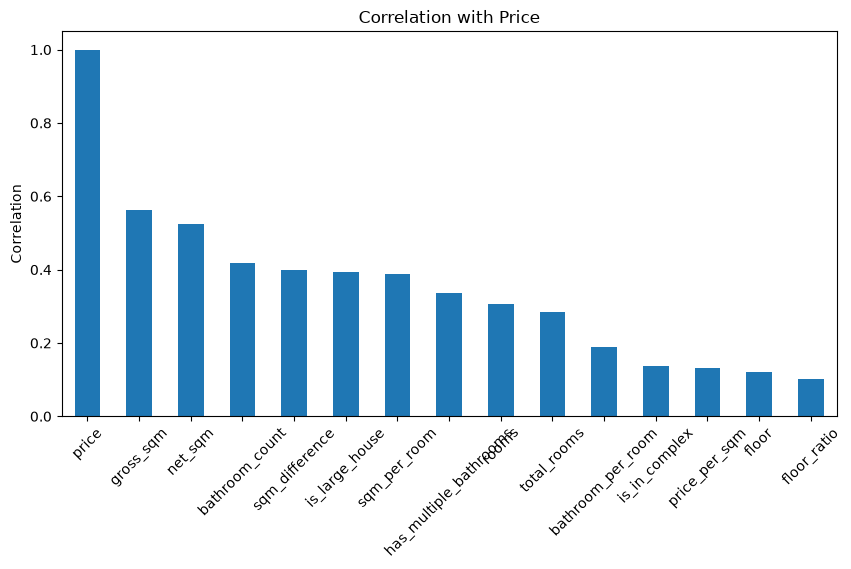

In [9]:
price_corr.head(15).plot.bar(figsize=(10,5))

plt.title("Correlation with Price")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()